In [104]:
import pandas as pd
import numpy as np

In [105]:
from pathlib import Path
BASE_DIR = Path.cwd().parent

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
DB_DIR = BASE_DIR / "data" / "db"
df = pd.read_csv(
    BASE_DIR / "data" / "raw" / "02_nav_history.csv"
)
print(df.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [107]:
df['date']=pd.to_datetime(df['date'])

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [109]:
df.isnull().mean()

amfi_code    0.0
date         0.0
nav          0.0
dtype: float64

In [110]:
df=df.sort_values(['amfi_code','date'])

In [111]:
df.duplicated().sum()

0

In [112]:
df['nav'].isnull().mean()*100

0.0

In [113]:
df['nav'] = (
    df.groupby('amfi_code')['nav']
      .ffill()
)

In [114]:
invalid_nav = df[df['nav'] <= 0]

print(invalid_nav)

Empty DataFrame
Columns: [amfi_code, date, nav]
Index: []


In [115]:
df = df[df['nav'] > 0]

In [116]:
df.dtypes

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object

In [117]:
nav_df_full = (
    df.set_index("date")
    .groupby("amfi_code", group_keys=False)
    .apply(
        lambda x: x.reindex(
            pd.date_range(x.index.min(), x.index.max(), freq="D")
        ).ffill()
    )
    .reset_index()
    .rename(columns={"index": "date"})
)


C:\Users\pushk\AppData\Local\Temp\ipykernel_29900\3080383373.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [118]:
nav_df_full.head()

,date,amfi_code,nav
0,2022-01-03,100016.0,520.4608
1,2022-01-04,100016.0,515.0971
2,2022-01-05,100016.0,521.7239
3,2022-01-06,100016.0,515.7880
4,2022-01-07,100016.0,515.1639


In [119]:
nav_df_full.to_csv(
    PROCESSED_DIR / "nav_history_clean.csv",
    index=False
)

**********
# Clean investor_transactions.csv — standardise transaction_type values (SIP/Lumpsum/Redemption), validate amount > 0, fix date formats, check KYC status enum values.

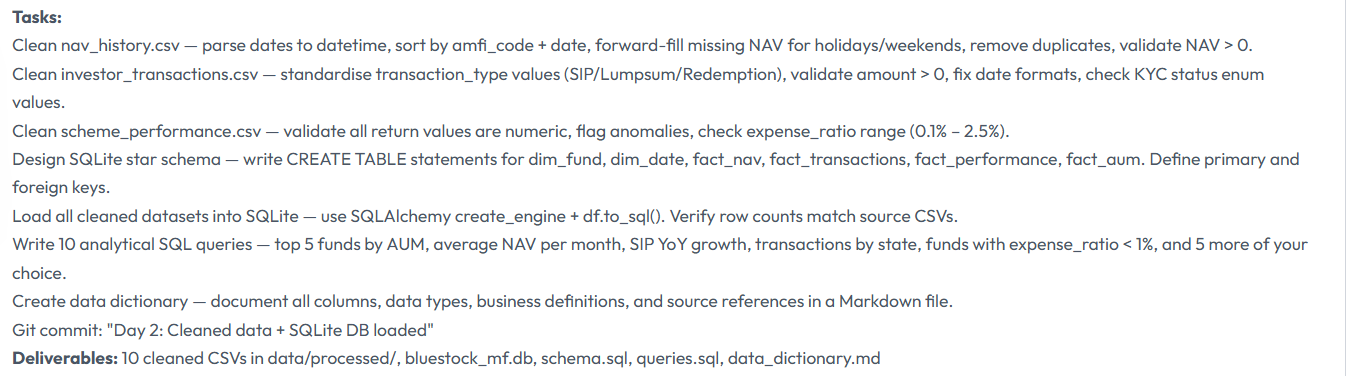

In [120]:
investor_df = pd.read_csv(RAW_DIR / "08_investor_transactions.csv")

In [121]:
investor_df.isnull().mean()*100

investor_id           0.0
transaction_date      0.0
amfi_code             0.0
transaction_type      0.0
amount_inr            0.0
state                 0.0
city                  0.0
city_tier             0.0
age_group             0.0
gender                0.0
annual_income_lakh    0.0
payment_mode          0.0
kyc_status            0.0
dtype: float64

In [122]:
investor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [123]:
VALID_TYPES = {"sip": "SIP", "lumpsum": "Lumpsum", "redemption": "Redemption"}
investor_df["transaction_type"] = (
    investor_df["transaction_type"]
    .str.strip()
    .str.lower()
    .map(VALID_TYPES)
)
investor_df["transaction_type"].value_counts(dropna=False)

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

# validate amount > 0

In [124]:
investor_df['transaction_date']=pd.to_datetime(investor_df['transaction_date'])

In [125]:
investor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  object        
 1   transaction_date    32778 non-null  datetime64[ns]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  object        
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  object        
 6   city                32778 non-null  object        
 7   city_tier           32778 non-null  object        
 8   age_group           32778 non-null  object        
 9   gender              32778 non-null  object        
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  object        
 12  kyc_status          32778 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), ob

In [126]:
investor_df['transaction_date'].isnull().sum()

0

In [127]:
# Drop rows where amount_inr <= 0 (invalid)
before = len(investor_df)
investor_df = investor_df[investor_df["amount_inr"] > 0].copy()
print(f"Dropped {before - len(investor_df)} invalid amount rows")

Dropped 0 invalid amount rows


In [128]:
investor_df

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32773,INV003340,2025-05-30,101207,Lumpsum,168029,Madhya Pradesh,Indore,T30,26-35,Male,22.5,Net Banking,Verified
32774,INV001838,2025-05-30,119093,SIP,2175,Uttar Pradesh,Kanpur,B30,46-55,Male,27.6,Mandate,Verified
32775,INV000074,2025-05-30,120504,SIP,25998,Rajasthan,Jaipur,T30,26-35,Female,8.4,UPI,Verified
32776,INV002929,2025-05-30,148568,SIP,459,West Bengal,Kolkata,T30,26-35,Male,13.0,Mandate,Verified


In [129]:
investor_df['kyc_status'].value_counts()

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

In [130]:
investor_df.to_csv(PROCESSED_DIR / "investor_transactions_clean.csv",index=False)

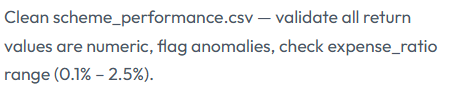

In [131]:
scheme_df = pd.read_csv(RAW_DIR / "07_scheme_performance.csv")

In [132]:
scheme_df.isnull().mean()*100

amfi_code             0.0
scheme_name           0.0
fund_house            0.0
category              0.0
plan                  0.0
return_1yr_pct        0.0
return_3yr_pct        0.0
return_5yr_pct        0.0
benchmark_3yr_pct     0.0
alpha                 0.0
beta                  0.0
sharpe_ratio          0.0
sortino_ratio         0.0
std_dev_ann_pct       0.0
max_drawdown_pct      0.0
aum_crore             0.0
expense_ratio_pct     0.0
morningstar_rating    0.0
risk_grade            0.0
dtype: float64

In [133]:
scheme_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     object 
 2   fund_house          40 non-null     object 
 3   category            40 non-null     object 
 4   plan                40 non-null     object 
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ra

In [134]:
returns=['return_1yr_pct','return_3yr_pct','return_5yr_pct']

for col in  returns:
    scheme_df[col]=pd.to_numeric(scheme_df[col])

In [135]:
scheme_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     object 
 2   fund_house          40 non-null     object 
 3   category            40 non-null     object 
 4   plan                40 non-null     object 
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ra

<Axes: >

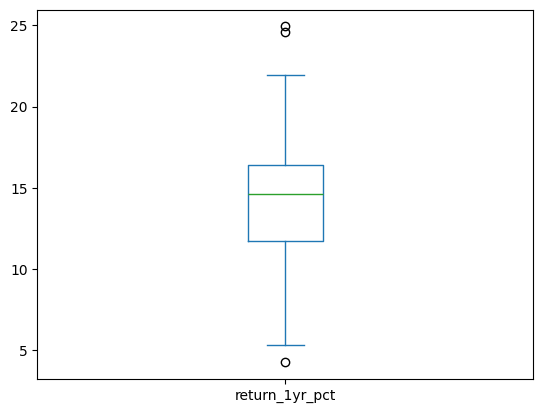

In [136]:
scheme_df['return_1yr_pct'].plot(kind='box')

<Axes: >

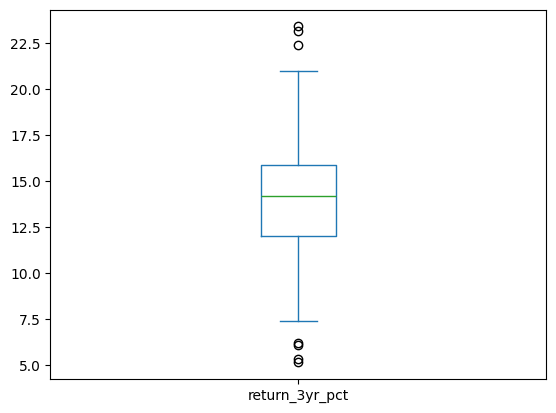

In [137]:
scheme_df['return_3yr_pct'].plot(kind='box')

<Axes: >

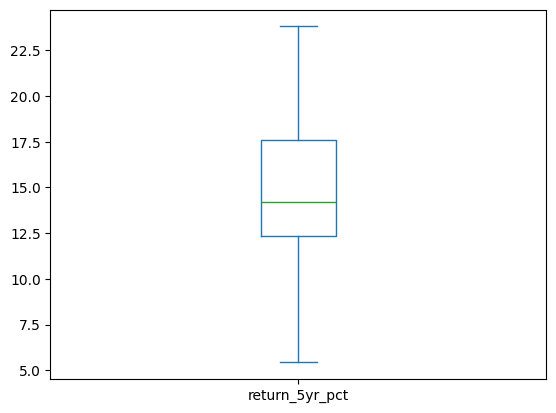

In [138]:
scheme_df['return_5yr_pct'].plot(kind='box')

In [139]:
for col in returns:
    Q1 = scheme_df[col].quantile(0.25)
    Q3 = scheme_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    scheme_df[f'{col}_anomaly'] = (
        (scheme_df[col] < lower) |
        (scheme_df[col] > upper)
    )

In [140]:
anomalies = scheme_df[scheme_df[[f'{c}_anomaly' for c in returns]].any(axis=1)]

In [141]:
anomalies

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_1yr_pct_anomaly,return_3yr_pct_anomaly,return_5yr_pct_anomaly
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.35,25.0,-13.35,19259,1.43,5,Very High,True,True,False
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,1.67,25.0,-24.78,36061,0.72,4,Very High,False,True,False
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,2.11,4.0,-2.30,24101,0.77,5,Low,False,True,False
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,...,2.38,4.0,-2.23,30030,0.55,4,Low,False,True,False
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,...,9.70,0.5,-3.81,27623,0.60,3,Low,True,True,False
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,1.47,25.0,-23.61,41613,1.53,5,Very High,True,True,False
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,...,8.76,0.5,-3.66,38995,0.79,5,Low,False,True,False


In [142]:
scheme_df=scheme_df.drop(columns=['return_1yr_pct_anomaly','return_3yr_pct_anomaly','return_5yr_pct_anomaly'])

# These are 7 rows that are outliers considered anomalies — kept in data, flagged only

# Validate expense_ratio_pct is within allowed range: 0.1% – 2.5%

In [143]:
((scheme_df['expense_ratio_pct']<0.1) | (scheme_df['expense_ratio_pct']>2.5)).sum()

0

# No expense_ratio_pct values fall outside the 0.1–2.5% range — all valid

In [144]:
scheme_df.to_csv(PROCESSED_DIR / "scheme_performance_clean.csv",index=False)

# Cleaning  aum

In [145]:
amu_df = pd.read_csv(RAW_DIR / "03_aum_by_fund_house.csv")

In [146]:
amu_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [147]:
amu_df.isnull().mean()

date              0.0
fund_house        0.0
aum_lakh_crore    0.0
aum_crore         0.0
num_schemes       0.0
dtype: float64

In [148]:
amu_df.duplicated().mean()

0.0

In [149]:
amu_df['date']=pd.to_datetime(amu_df['date'])

In [150]:
amu_df.to_csv(PROCESSED_DIR / "aum_by_fund_house_clean.csv",index=False)

# monthly sip inflows

In [151]:
sip_df=pd.read_csv(RAW_DIR / "04_monthly_sip_inflows.csv")

In [152]:
sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [153]:
sip_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.4+ KB


In [154]:
sip_df.isnull().mean()*100

month                         0.0
sip_inflow_crore              0.0
active_sip_accounts_crore     0.0
new_sip_accounts_lakh         0.0
sip_aum_lakh_crore            0.0
yoy_growth_pct               25.0
dtype: float64

<Axes: ylabel='Density'>

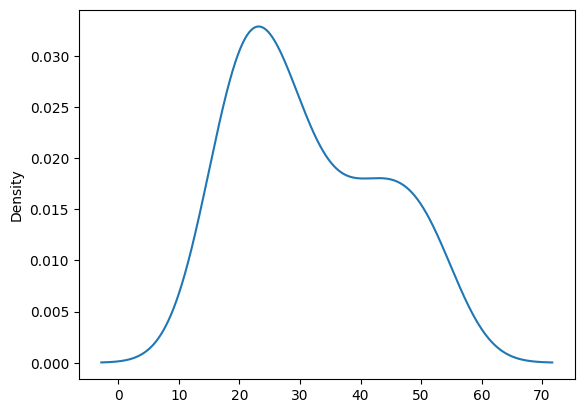

In [155]:
sip_df['yoy_growth_pct'].plot(kind='kde')

In [156]:
sip_df['yoy_growth_pct']=sip_df['yoy_growth_pct'].bfill()

<Axes: ylabel='Density'>

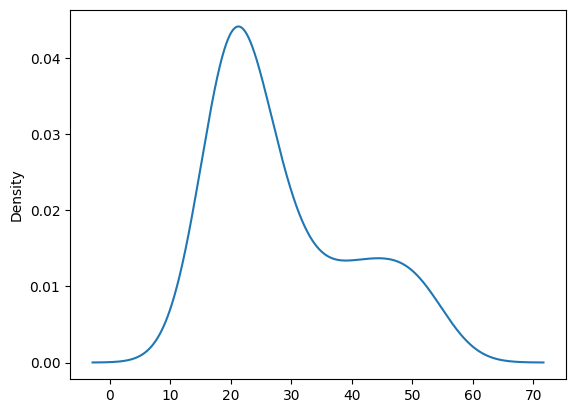

In [157]:
sip_df['yoy_growth_pct'].plot(kind='kde')

In [158]:
sip_df.to_csv(PROCESSED_DIR / "monthly_sip_inflows_clean.csv",index=False)

# category_inflows

In [159]:
category_df = pd.read_csv(RAW_DIR / "05_category_inflows.csv")

In [160]:
category_df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [161]:
category_df.duplicated().sum()

0

In [162]:
category_df.isnull().mean()

month               0.0
category            0.0
net_inflow_crore    0.0
dtype: float64

In [163]:
category_df['category'].unique()

array(['Large Cap', 'Mid Cap', 'Small Cap', 'Flexi Cap',
       'Large & Mid Cap', 'ELSS', 'Value/Contra', 'Sectoral/Thematic',
       'Liquid', 'Short Duration', 'Gilt', 'Hybrid'], dtype=object)

In [164]:
category_df.to_csv(PROCESSED_DIR / "category_inflows_clean.csv", index=False)

In [165]:
folio_df = pd.read_csv(RAW_DIR / "06_industry_folio_count.csv")

In [166]:
folio_df['month'] = pd.to_datetime(folio_df['month']).dt.strftime('%Y-%m')

In [167]:
folio_df.isnull().mean()

month                  0.0
total_folios_crore     0.0
equity_folios_crore    0.0
debt_folios_crore      0.0
hybrid_folios_crore    0.0
others_folios_crore    0.0
dtype: float64

In [168]:
folio_df.duplicated().sum()

0

In [169]:
folio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     object 
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.1+ KB


In [170]:
folio_df.to_csv(PROCESSED_DIR / "industry_folio_count_clean.csv",index=False)

In [171]:
portfolio_df = pd.read_csv(RAW_DIR / "09_portfolio_holdings.csv")

In [172]:
portfolio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [173]:
portfolio_df['portfolio_date']=pd.to_datetime(portfolio_df['portfolio_date'])

In [174]:
portfolio_df['stock_symbol'].unique()

array(['POWERGRID', 'HDFCBANK', 'GRASIM', 'DRREDDY', 'ASIANPAINT', 'NTPC',
       'DIVISLAB', 'BHARTIARTL', 'HCLTECH', 'MARUTI', 'INFY', 'ICICIBANK',
       'TATAMOTOR', 'CIPLA', 'BAJFINANCE', 'SUNPHARMA', 'ULTRACEMCO',
       'WIPRO', 'TCS', 'RELIANCE', 'M&M', 'AXISBANK', 'KOTAKBANK',
       'TITAN', 'HINDUNILVR', 'INDUSINDBK', 'NESTLEIND', 'LT', 'SBIN',
       'ADANIPORT'], dtype=object)

In [175]:
portfolio_df.isnull().mean()

amfi_code            0.0
stock_symbol         0.0
stock_name           0.0
sector               0.0
weight_pct           0.0
market_value_cr      0.0
current_price_inr    0.0
portfolio_date       0.0
dtype: float64

In [176]:
portfolio_df.duplicated().sum()

0

In [177]:
portfolio_df['stock_name'].unique()

array(['Power Grid Corporation', 'HDFC Bank Ltd', 'Grasim Industries Ltd',
       "Dr. Reddy's Laboratories", 'Asian Paints Ltd', 'NTPC Ltd',
       "Divi's Laboratories", 'Bharti Airtel Ltd', 'HCL Technologies Ltd',
       'Maruti Suzuki India Ltd', 'Infosys Ltd', 'ICICI Bank Ltd',
       'Tata Motors Ltd', 'Cipla Ltd', 'Bajaj Finance Ltd',
       'Sun Pharmaceutical Industries', 'UltraTech Cement Ltd',
       'Wipro Ltd', 'Tata Consultancy Services',
       'Reliance Industries Ltd', 'Mahindra & Mahindra Ltd',
       'Axis Bank Ltd', 'Kotak Mahindra Bank', 'Titan Company Ltd',
       'Hindustan Unilever Ltd', 'IndusInd Bank Ltd', 'Nestle India Ltd',
       'Larsen & Toubro Ltd', 'State Bank of India',
       'Adani Ports & SEZ Ltd'], dtype=object)

In [178]:
portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [179]:
portfolio_df.to_csv(PROCESSED_DIR / "portfolio_holdings_clean.csv",index=False)

In [180]:
benchmark_df = pd.read_csv(RAW_DIR / "10_benchmark_indices.csv")

In [181]:
benchmark_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [182]:
benchmark_df.isnull().mean()

date           0.0
index_name     0.0
close_value    0.0
dtype: float64

In [183]:
benchmark_df['date']=pd.to_datetime(benchmark_df['date'])

In [184]:
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [185]:
benchmark_df.duplicated().sum()

0

In [186]:
benchmark_df['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [187]:
benchmark_df.to_csv(PROCESSED_DIR / "benchmark_indices_clean.csv",index=False)

In [188]:
fund_df = pd.read_csv(RAW_DIR / "01_fund_master.csv")

In [189]:
fund_df.isnull().mean()

amfi_code             0.0
fund_house            0.0
scheme_name           0.0
category              0.0
sub_category          0.0
plan                  0.0
launch_date           0.0
benchmark             0.0
expense_ratio_pct     0.0
exit_load_pct         0.0
min_sip_amount        0.0
min_lumpsum_amount    0.0
fund_manager          0.0
risk_category         0.0
sebi_category_code    0.0
dtype: float64

In [190]:
fund_df.duplicated().sum()

0

In [191]:
fund_df['launch_date']=pd.to_datetime(fund_df['launch_date'])

In [192]:
fund_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [193]:
fund_df.to_csv(PROCESSED_DIR / "fund_master_clean.csv",index=False)

# Now all of the data is cleaned 

# SQLite Database Setup — Load Cleaned Data

## Step 1: Create SQLite engine

In [194]:
from pathlib import Path
from sqlalchemy import create_engine
BASE_DIR = Path.cwd().parent
(BASE_DIR / "data" / "db").mkdir(parents=True, exist_ok=True)
DB_PATH = BASE_DIR / "data" / "db" / "bluestock_mf.db"
engine = create_engine(f"sqlite:///{DB_PATH}")

print(DB_PATH)

C:\Users\pushk\OneDrive\Desktop\AIML\Blue Stocks\mutual-fund-analytics\data\db\bluestock_mf.db


In [195]:
engine

Engine(sqlite:///C:\Users\pushk\OneDrive\Desktop\AIML\Blue Stocks\mutual-fund-analytics\data\db\bluestock_mf.db)

In [199]:
df_fund = pd.read_csv(PROCESSED_DIR / "fund_master_clean.csv")
df_nav = pd.read_csv(PROCESSED_DIR / "nav_history_clean.csv")
df_transactions = pd.read_csv(PROCESSED_DIR / "investor_transactions_clean.csv")
df_performance = pd.read_csv(PROCESSED_DIR / "scheme_performance_clean.csv")
df_portfolio = pd.read_csv(PROCESSED_DIR / "portfolio_holdings_clean.csv")
df_aum = pd.read_csv(PROCESSED_DIR / "aum_by_fund_house_clean.csv")
df_sip = pd.read_csv(PROCESSED_DIR / "monthly_sip_inflows_clean.csv")

In [200]:
df_date = pd.DataFrame({
    "date": pd.to_datetime(df_nav["date"]).unique()
})
df_date = df_date.sort_values("date")
df_date["year"] = df_date["date"].dt.year
df_date["month"] = df_date["date"].dt.month
df_date["month_name"] = df_date["date"].dt.month_name()
df_date["quarter"] = df_date["date"].dt.quarter

In [201]:
df_fund.to_sql("dim_fund", engine, if_exists="replace", index=False)
df_date.to_sql("dim_date", engine, if_exists="replace", index=False)
df_nav.to_sql("fact_nav", engine, if_exists="replace", index=False)
df_transactions.to_sql("fact_transactions", engine, if_exists="replace", index=False)
df_performance.to_sql("fact_performance", engine, if_exists="replace", index=False)
df_portfolio.to_sql("fact_portfolio", engine, if_exists="replace", index=False)
df_aum.to_sql("fact_aum", engine, if_exists="replace", index=False)
df_sip.to_sql("fact_sip_industry", engine, if_exists="replace", index=False)

48

In [202]:
dates = pd.to_datetime(nav_df["nav_date"]).drop_duplicates()

dim_date = pd.DataFrame({
    "date": dates
})

dim_date["date_id"] = dim_date["date"].dt.strftime("%Y%m%d").astype(int)
dim_date["year"] = dim_date["date"].dt.year
dim_date["month"] = dim_date["date"].dt.month
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date["is_weekday"] = (dim_date["date"].dt.dayofweek < 5).astype(int)

dim_date.to_sql(
    "dim_date",
    engine,
    if_exists="replace",
    index=False
)

1608

In [209]:
import sqlite3
BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "data" / "db" / "bluestock_mf.db"
SQL_PATH = BASE_DIR / "sql" / "queries.sql"
conn = sqlite3.connect(DB_PATH)
with open(SQL_PATH, "r", encoding="utf-8") as f:
    queries = f.read()
conn.executescript(queries)

conn.commit()
conn.close()

print("Queries executed successfully!")

Queries executed successfully!
